# DeconfoundingFM: observational → counterfactual distributions

This is the main runnable demonstration of **DeconfoundingFM**. We use a deliberately structured two-dimensional outcome so that the modeling advantage is visible rather than hidden by an easy Gaussian target.

We generate

$$
X\sim \mathrm{Unif}[-1,1], \qquad
A\mid X=x\sim \mathrm{Bernoulli}(\sigma(3.2x)),
$$

and

$$
Y = \mu_Z + s(X) + \tau A + \varepsilon,
$$

where $\mu_Z$ is a **three-component Gaussian-mixture structure** with well-separated modes. The effect of $X$ on $Y$ is intentionally moderate relative to this large-scale structure. Thus $P(Y\mid A=1)$ and $P(Y(1))$ already share the difficult multimodal geometry and differ mainly through the covariate-mixing distribution.

We compare three target flows, each trained for **exactly 10,000 optimizer iterations** and using the **same fitted nuisance models**:

1. **DeconfoundingFM** — empirical $P(Y\mid A=a)$ base with the independent coupling;
2. **OT-DeconfoundingFM** — the same empirical base with the minibatch entropic-OT coupling;
3. **Gaussian-base FM** — the same debiased objective but starting from $N(0,I)$.

The true $P(Y(1))$ is available only because this is a synthetic demonstration; it is used for visualization and evaluation, not for training.


The committed outputs below were generated with this exact 10,000-iteration configuration so the results are visible directly in GitHub before rerunning the notebook.


In [1]:
from pathlib import Path
import sys

# Allow the notebook to run directly from a fresh clone before editable install.
_here = Path.cwd().resolve()
for _root in (_here, _here.parent):
    if (_root / "src" / "deconfoundingfm").exists():
        sys.path.insert(0, str(_root / "src"))
        break

import math
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import torch

from deconfoundingfm import DeconfoundingFM, DeconfoundingFMConfig
from deconfoundingfm.integrators import path_energy_midpoint

SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# For this small CPU example, one thread is faster and more reproducible than
# dispatching many tiny matrix operations across a large CPU thread pool.
if DEVICE == "cpu":
    torch.set_num_threads(1)

print("device:", DEVICE)


device: cpu


## 1. Generate structured observational data


In [2]:
# Three well-separated modes carry most of the geometry of Y.
CENTERS = torch.tensor([
    [-3.4, -1.6],
    [ 0.0,  3.0],
    [ 3.4, -1.4],
])
MIXTURE_WEIGHTS = torch.tensor([0.34, 0.32, 0.34])
NOISE_SD = 0.28
X_EFFECT = 0.95
PROPENSITY_SLOPE = 3.2
TREATMENT_SHIFT = torch.tensor([0.7, 0.35])


def sample_structural_noise(n, device="cpu"):
    centers = CENTERS.to(device)
    weights = MIXTURE_WEIGHTS.to(device)
    component = torch.multinomial(weights, n, replacement=True)
    return centers[component] + NOISE_SD * torch.randn(n, 2, device=device)


def sample_outcome(x, a):
    x = x.reshape(-1)
    a = a.reshape(-1)
    structural = sample_structural_noise(len(x), x.device)
    # X changes the outcome, but only moderately relative to the mode separation.
    x_shift = torch.stack([
        X_EFFECT * x,
        0.22 * torch.sin(math.pi * x),
    ], dim=1)
    return structural + x_shift + a[:, None] * TREATMENT_SHIFT.to(x.device)


n = 1_000
X = 2 * torch.rand(n, 1) - 1
propensity = torch.sigmoid(PROPENSITY_SLOPE * X[:, 0])
A = torch.bernoulli(propensity)
Y = sample_outcome(X, A)

# Synthetic reference samples from P(Y(1)); never supplied to the fitted models.
n_reference = 2_500
X_reference = 2 * torch.rand(n_reference, 1) - 1
Y1_reference = sample_outcome(X_reference, torch.ones(n_reference))
Y1_observed = Y[A == 1]

print(f"n = {n:,}")
print(f"arm counts: A=0: {(A == 0).sum().item()}, A=1: {(A == 1).sum().item()}")
print(f"true propensity range in this sample: [{propensity.min():.3f}, {propensity.max():.3f}]")


n = 1,000
arm counts: A=0: 512, A=1: 488
true propensity range in this sample: [0.039, 0.961]


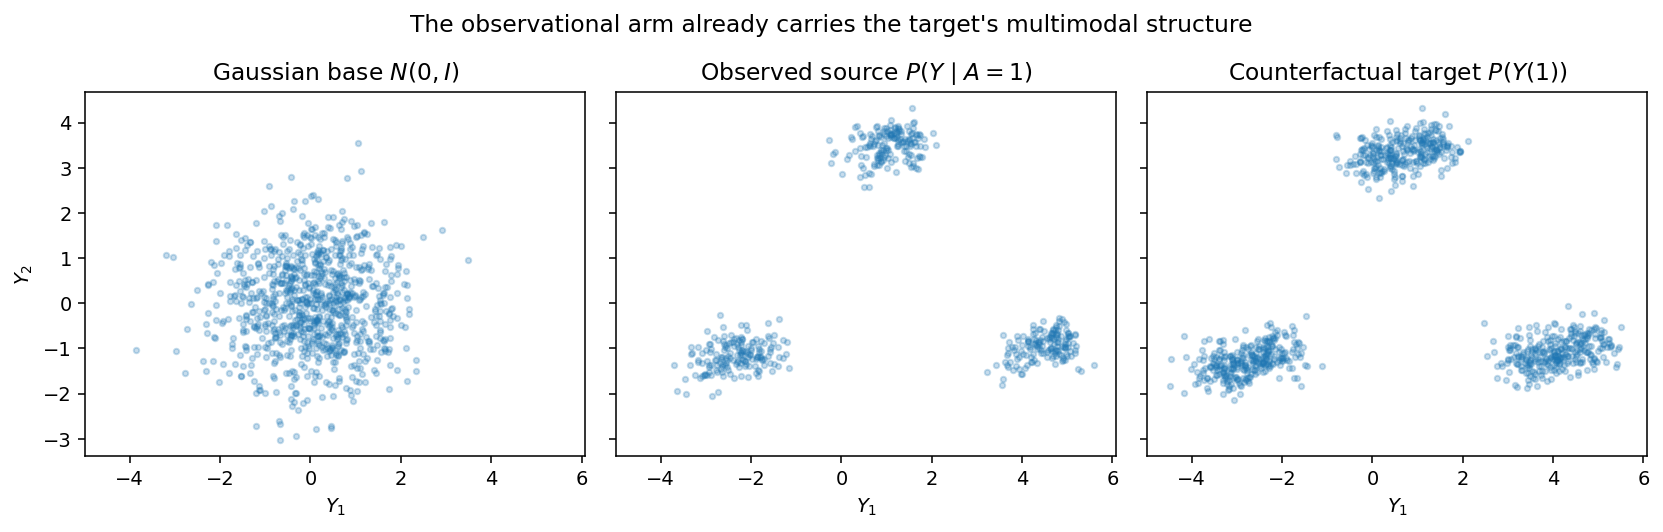

In [3]:
gaussian_base = torch.randn(900, 2)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
axes[0].scatter(gaussian_base[:, 0], gaussian_base[:, 1], s=8, alpha=0.25)
axes[0].set_title(r"Gaussian base $N(0,I)$")
axes[1].scatter(Y1_observed[:, 0], Y1_observed[:, 1], s=8, alpha=0.25)
axes[1].set_title(r"Observed source $P(Y\mid A=1)$")
axes[2].scatter(Y1_reference[:900, 0], Y1_reference[:900, 1], s=8, alpha=0.25)
axes[2].set_title(r"Counterfactual target $P(Y(1))$")
for ax in axes:
    ax.set_xlabel(r"$Y_1$")
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel(r"$Y_2$")
fig.suptitle("The observational arm already carries the target's multimodal structure")
plt.tight_layout()
plt.show()


## 2. Fit the nuisance models and DeconfoundingFM

The first fit estimates the propensity and conditional outcome nuisances from the observational data. The target flow then receives an **exact budget of 10,000 optimizer updates** via `iterations=10_000`. The following OT and Gaussian comparisons reuse these same fitted nuisances.


In [4]:
config = DeconfoundingFMConfig(
    device=DEVICE,
    seed=SEED,
    coupling="independent",
    architecture="mlp",
    base_kind="empirical",
    hidden=64,
    layers=2,
    batch_size=32,
    lr=1e-4,
    iterations=10_000,
    ode_steps=20,
    nuisance_hidden=64,
    nuisance_layers=2,
    nuisance_batch_size=512,
    nuisance_lr=1e-3,
    nuisance_epochs=120,
    nuisance_ode_steps=14,
    nuisance_base_kind="empirical",
    propensity_trees=100,
    propensity_max_depth=4,
    plugin_reservoir=4,
    plugin_batch=1,
    # Lightweight minibatch-EOT settings keep the notebook CPU-runnable.
    eot_iterations=3,
    eot_source_batch=16,
    eot_epsilon_scale=0.1,
)

decfm = DeconfoundingFM(config).fit(X, A, Y, verbose=False)
print("DeconfoundingFM iterations:", decfm.diagnostics()["training_iterations"])


DeconfoundingFM iterations: 10000


## 3. Fit OT-DeconfoundingFM

`coupling="ot"` activates the package's minibatch **entropic optimal-transport** conditional. It uses the same observational base, target architecture, optimization budget, propensity model, and conditional outcome model as DeconfoundingFM above; only the coupling is changed.


In [5]:
ot_config = replace(config, coupling="ot")
ot_decfm = DeconfoundingFM(
    ot_config,
    outcome_model=decfm.outcome_model,
    propensity_model=decfm.propensity_model,
).fit(X, A, Y, verbose=False)

print("OT-DeconfoundingFM iterations:", ot_decfm.diagnostics()["training_iterations"])
print("last adaptive EOT epsilon:", f"{ot_decfm.diagnostics()['eot_epsilon_last']:.4f}")


OT-DeconfoundingFM iterations: 10000
last adaptive EOT epsilon: 2.4384


## 4. Gaussian-base comparison

The baseline again uses the **same debiased target objective and the same fitted nuisances**, but replaces the empirical source $P(Y\mid A=a)$ by $N(0,I)$. This isolates how much additional structure the target flow must learn when it does not start from the observational outcome geometry.


In [6]:
gaussian_config = replace(config, base_kind="gaussian", coupling="independent")
gaussian_fm = DeconfoundingFM(
    gaussian_config,
    outcome_model=decfm.outcome_model,
    propensity_model=decfm.propensity_model,
).fit(X, A, Y, verbose=False)

print("Gaussian-base FM iterations:", gaussian_fm.diagnostics()["training_iterations"])


Gaussian-base FM iterations: 10000


In [7]:
@torch.no_grad()
def sliced_w2(x, y, n_projections=128, seed=123):
    """Small deterministic SW2 diagnostic for this 2D demo."""
    x = x.detach().cpu()
    y = y.detach().cpu()
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    generator = torch.Generator().manual_seed(seed)
    directions = torch.randn(n_projections, x.shape[1], generator=generator)
    directions = directions / directions.norm(dim=1, keepdim=True)
    xp = (x @ directions.T).sort(dim=0).values
    yp = (y @ directions.T).sort(dim=0).values
    return torch.sqrt(((xp - yp) ** 2).mean()).item()


n_eval = 1_200
y_ref_eval = Y1_reference[:n_eval].cpu()

source_generator = torch.Generator().manual_seed(999)
source_idx = torch.randint(len(Y1_observed), (n_eval,), generator=source_generator)
y_source_eval = Y1_observed[source_idx].cpu()

samples = {}
for i, (name, model) in enumerate([
    ("decfm", decfm),
    ("ot", ot_decfm),
    ("gaussian", gaussian_fm),
]):
    torch.manual_seed(2000 + i)
    samples[name] = model.sample(a=1, n=n_eval).cpu()

y_decfm = samples["decfm"]
y_ot = samples["ot"]
y_gaussian = samples["gaussian"]

sw2_source = sliced_w2(y_source_eval, y_ref_eval)
sw2_decfm = sliced_w2(y_decfm, y_ref_eval)
sw2_ot = sliced_w2(y_ot, y_ref_eval)
sw2_gaussian = sliced_w2(y_gaussian, y_ref_eval)

print(f"SW2 observed source       -> target: {sw2_source:.3f}")
print(f"SW2 DeconfoundingFM       -> target: {sw2_decfm:.3f}")
print(f"SW2 OT-DeconfoundingFM    -> target: {sw2_ot:.3f}")
print(f"SW2 Gaussian-base FM      -> target: {sw2_gaussian:.3f}")


SW2 observed source       -> target: 0.432
SW2 DeconfoundingFM       -> target: 0.393
SW2 OT-DeconfoundingFM    -> target: 0.262
SW2 Gaussian-base FM      -> target: 0.588


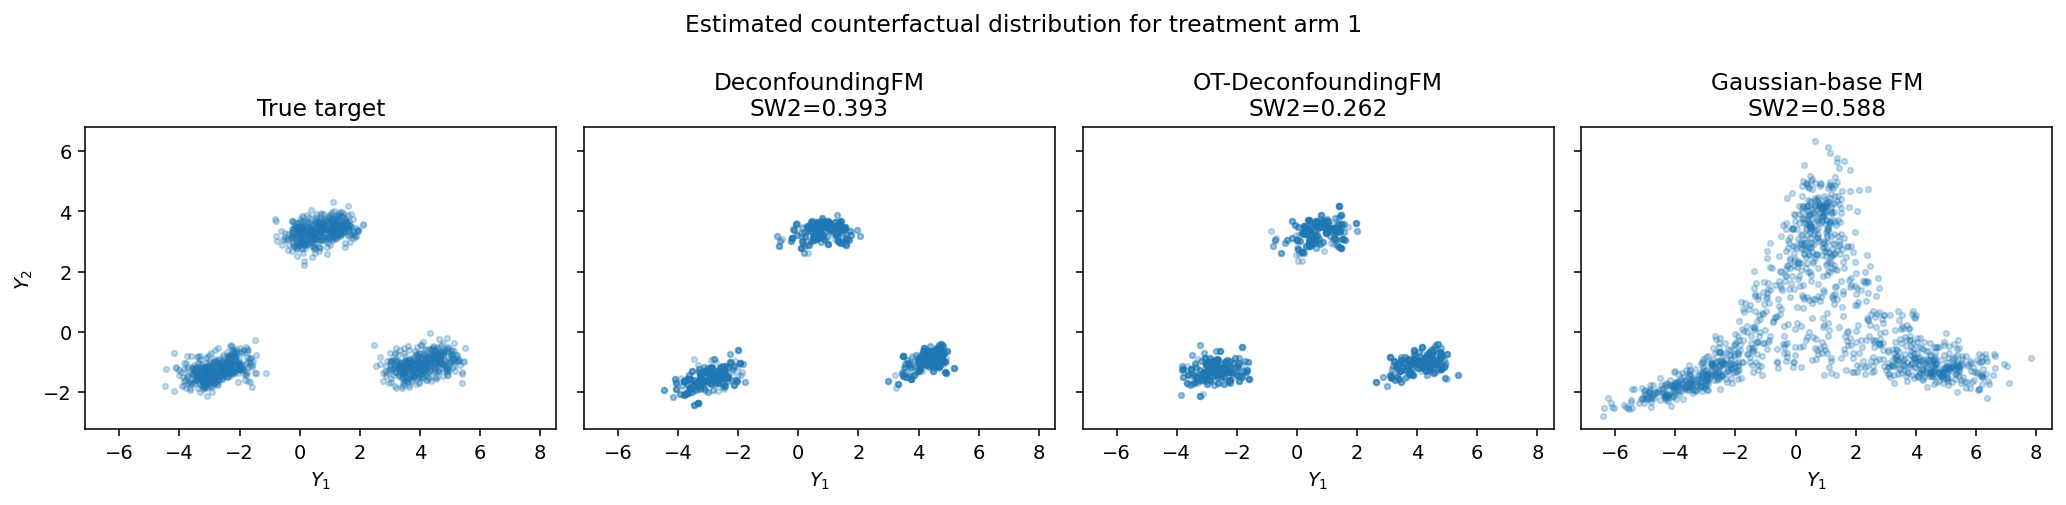

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=True, sharey=True)
items = [
    (y_ref_eval, "True target"),
    (y_decfm, f"DeconfoundingFM\nSW2={sw2_decfm:.3f}"),
    (y_ot, f"OT-DeconfoundingFM\nSW2={sw2_ot:.3f}"),
    (y_gaussian, f"Gaussian-base FM\nSW2={sw2_gaussian:.3f}"),
]
for ax, (samples, title) in zip(axes, items):
    ax.scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.25)
    ax.set_title(title)
    ax.set_xlabel(r"$Y_1$")
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel(r"$Y_2$")
fig.suptitle("Estimated counterfactual distribution for treatment arm 1")
plt.tight_layout()
plt.show()


## 5. Visualize the learned transports

The OT variant is intended to target a lower-energy deconfounding transport in dimensions greater than one. We therefore show both the trajectories and a simple kinetic-energy diagnostic evaluated on the same observed arm-1 starting points.


In [9]:
@torch.no_grad()
def trace_flow(model, y0, a=1, steps=24):
    y = y0.clone().to(model.device)
    trajectory = [y.cpu()]
    dt = 1.0 / steps
    context = torch.full((len(y), 1), float(a), device=model.device)
    for k in range(steps):
        t0 = torch.full((len(y),), k * dt, device=model.device)
        tmid = torch.full((len(y),), (k + 0.5) * dt, device=model.device)
        k1 = model.velocity_(y, t0, context)
        ymid = y + 0.5 * dt * k1
        k2 = model.velocity_(ymid, tmid, context)
        y = y + dt * k2
        trajectory.append(y.cpu())
    return torch.stack(trajectory)


n_paths = 28
path_generator = torch.Generator().manual_seed(321)
source_paths = Y1_observed[torch.randperm(len(Y1_observed), generator=path_generator)[:n_paths]]
gaussian_generator = torch.Generator().manual_seed(654)
gaussian_paths = torch.randn(n_paths, 2, generator=gaussian_generator)
traj_decfm = trace_flow(decfm, source_paths)
traj_ot = trace_flow(ot_decfm, source_paths)
traj_gaussian = trace_flow(gaussian_fm, gaussian_paths)

# Same empirical source points for the two deconfounding flows.
ctx = torch.ones(len(source_paths), 1, device=decfm.device)
energy_decfm = path_energy_midpoint(
    decfm.velocity_, source_paths.to(decfm.device), context=ctx, steps=32
).item()
energy_ot = path_energy_midpoint(
    ot_decfm.velocity_, source_paths.to(ot_decfm.device), context=ctx.to(ot_decfm.device), steps=32
).item()

print(f"Mean path energy, DeconfoundingFM:    {energy_decfm:.3f}")
print(f"Mean path energy, OT-DeconfoundingFM: {energy_ot:.3f}")


Mean path energy, DeconfoundingFM:    6.623
Mean path energy, OT-DeconfoundingFM: 0.189


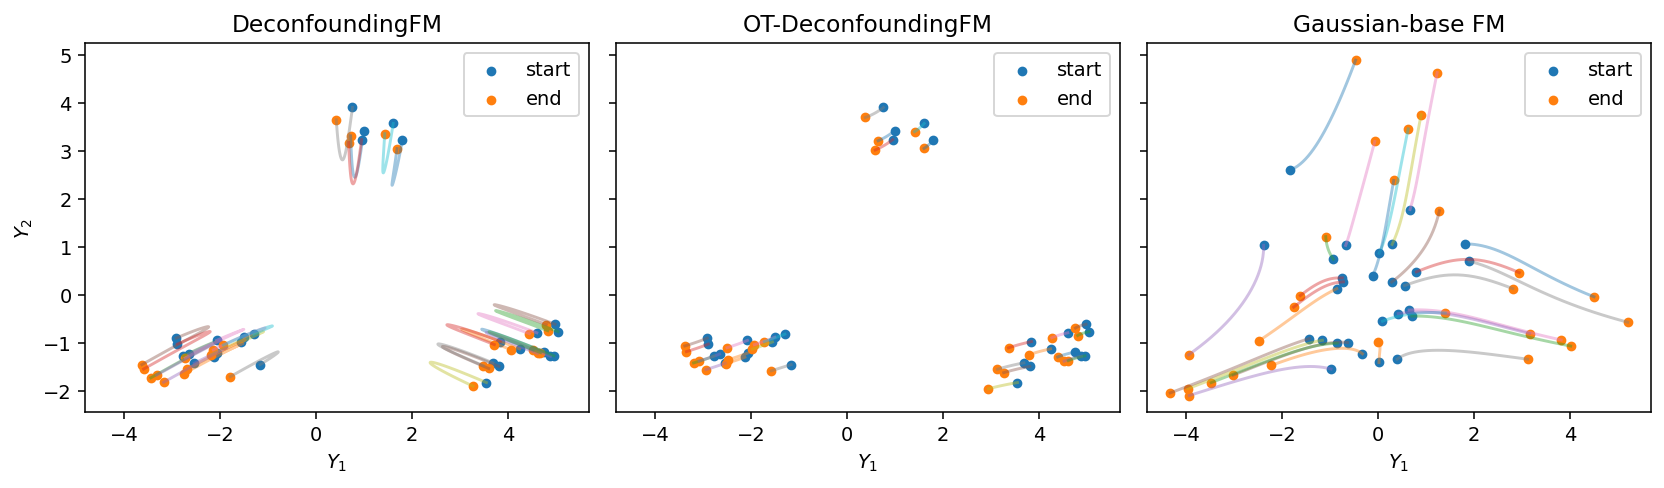

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
trajectories = [
    (traj_decfm, "DeconfoundingFM"),
    (traj_ot, "OT-DeconfoundingFM"),
    (traj_gaussian, "Gaussian-base FM"),
]
for ax, (traj, title) in zip(axes, trajectories):
    for j in range(n_paths):
        ax.plot(traj[:, j, 0], traj[:, j, 1], alpha=0.42)
    ax.scatter(traj[0, :, 0], traj[0, :, 1], s=16, label="start")
    ax.scatter(traj[-1, :, 0], traj[-1, :, 1], s=16, label="end")
    ax.set_title(title)
    ax.set_xlabel(r"$Y_1$")
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
axes[0].set_ylabel(r"$Y_2$")
plt.tight_layout()
plt.show()


## Takeaway

The three modes are mostly **outcome structure**, not confounding structure. Both DeconfoundingFM variants inherit that structure from $P(Y\mid A=1)$ and learn the smaller correction induced by replacing $P(X\mid A=1)$ with $P(X)$. OT-DeconfoundingFM additionally uses a minibatch entropic-OT coupling to encourage a simpler, lower-energy deconfounding transport. The Gaussian-base model instead has to learn the multimodal outcome geometry and the counterfactual reweighting simultaneously.

For real data, the same public API is `fit(X, A, Y)`, with `coupling="independent"` or `coupling="ot"`, followed by `sample(a=...)` or `transform(..., a=...)`.
